# 83 - Grounding DINO テキストプロンプト検出

## 概要
HuggingFace transformers の Grounding DINO (IDEA-Research) を用いて、
テキストプロンプトによるオープン語彙物体検出を実験する。
tiny / base モデルの比較、閾値パラメータの感度分析を行う。

## 手法
- Grounding DINO: テキストプロンプト → バウンディングボックス + ラベル
- プロンプト形式: `"person . bird . duck . laptop ."` (ピリオド区切り)
- モデル: `IDEA-Research/grounding-dino-tiny` (172M params)
- モデル: `IDEA-Research/grounding-dino-base` (341M params)

## 入力
- `data/images.duckdb` (image_catalog, object_detections テーブル)

## 出力
- `data/images.duckdb` (object_detections に Grounding DINO 結果追加)
- `data/83_grounding_dino_samples.png`
- `data/83_tiny_vs_base.png`

In [1]:
import time
import uuid
from pathlib import Path

import cv2
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from PIL import Image
from tqdm.notebook import tqdm
from transformers import GroundingDinoForObjectDetection, GroundingDinoProcessor

## 1. 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")

# Grounding DINO 設定
MODELS = {
    "tiny": "IDEA-Research/grounding-dino-tiny",
    "base": "IDEA-Research/grounding-dino-base",
}

# 検出パラメータ
BOX_THRESHOLD = 0.3
TEXT_THRESHOLD = 0.25

COMMIT_INTERVAL = 50

# 検出プロンプト（ピリオド区切り）
PROMPT_TEXT = "person . bird . duck . laptop . chair . table . microphone . screen . car . tree . building . tower . bench . lanyard . badge . food . cup . bottle . phone . book ."

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Prompt: {PROMPT_TEXT}")

Device: cuda
Prompt: person . bird . duck . laptop . chair . table . microphone . screen . car . tree . building . tower . bench . lanyard . badge . food . cup . bottle . phone . book .


## 2. tiny モデルで全画像を検出

In [3]:
model_id = MODELS["tiny"]
print(f"モデル読み込み中: {model_id}")

processor = GroundingDinoProcessor.from_pretrained(model_id)
model = GroundingDinoForObjectDetection.from_pretrained(model_id).to(DEVICE)
model.eval()

print(f"パラメータ数: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
if DEVICE == "cuda":
    print(f"GPU メモリ: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

モデル読み込み中: IDEA-Research/grounding-dino-tiny


The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

パラメータ数: 172.2M
GPU メモリ: 0.64 GB


In [4]:
conn = duckdb.connect(str(DB_PATH))

MODEL_NAME_TINY = "grounding-dino-tiny"

# 既存レコード削除
conn.execute("DELETE FROM object_detections WHERE model_name = ?", [MODEL_NAME_TINY])
conn.commit()

all_images = conn.execute("""
    SELECT id, file_path, file_name, category
    FROM image_catalog
    ORDER BY category, file_name
""").fetchdf()

print(f"処理対象: {len(all_images)} 画像")

処理対象: 378 画像


In [5]:
total_detections = 0
total_images = 0
errors = []
start_time = time.time()

for idx, (_, row) in enumerate(tqdm(all_images.iterrows(), total=len(all_images), desc="Grounding DINO tiny")):
    try:
        image = Image.open(row["file_path"]).convert("RGB")
        w, h = image.size

        inputs = processor(images=image, text=PROMPT_TEXT, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            outputs = model(**inputs)

        results = processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD,
            target_sizes=[(h, w)],
        )

        total_images += 1

        for result in results:
            boxes = result["boxes"].cpu().numpy()
            scores = result["scores"].cpu().numpy()
            labels = result["text_labels"]

            for box, score, label in zip(boxes, scores, labels):
                detection_id = str(uuid.uuid4())
                x1, y1, x2, y2 = [float(v) for v in box]

                conn.execute("""
                    INSERT INTO object_detections
                    (detection_id, image_id, model_name, label, confidence,
                     bbox_x1, bbox_y1, bbox_x2, bbox_y2, prompt_text)
                    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                """, [
                    detection_id, row["id"], MODEL_NAME_TINY,
                    label.strip(), float(score),
                    x1, y1, x2, y2, PROMPT_TEXT
                ])
                total_detections += 1

    except Exception as e:
        errors.append((row["id"], str(e)))

    if (idx + 1) % COMMIT_INTERVAL == 0:
        conn.commit()

conn.commit()

elapsed = time.time() - start_time
print(f"\n処理完了 (Grounding DINO tiny):")
print(f"  処理画像数: {total_images}")
print(f"  総検出数: {total_detections}")
print(f"  平均検出数/画像: {total_detections / max(total_images, 1):.1f}")
print(f"  処理速度: {total_images / max(elapsed, 0.01):.1f} img/s")
print(f"  処理時間: {elapsed:.1f} 秒")
print(f"  エラー数: {len(errors)}")
if errors:
    for id_, err in errors[:5]:
        print(f"    {id_}: {err}")

Grounding DINO tiny:   0%|          | 0/378 [00:00<?, ?it/s]


処理完了 (Grounding DINO tiny):
  処理画像数: 378
  総検出数: 7536
  平均検出数/画像: 19.9
  処理速度: 2.9 img/s
  処理時間: 128.4 秒
  エラー数: 0


## 3. base モデルで全画像を検出

In [6]:
# tiny モデルを解放
del model, processor
torch.cuda.empty_cache()

# base モデルを読み込み
model_id = MODELS["base"]
print(f"モデル読み込み中: {model_id}")

processor = GroundingDinoProcessor.from_pretrained(model_id)
model = GroundingDinoForObjectDetection.from_pretrained(model_id).to(DEVICE)
model.eval()

print(f"パラメータ数: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
if DEVICE == "cuda":
    print(f"GPU メモリ: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

モデル読み込み中: IDEA-Research/grounding-dino-base


Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

パラメータ数: 232.3M
GPU メモリ: 0.94 GB


In [7]:
MODEL_NAME_BASE = "grounding-dino-base"

conn.execute("DELETE FROM object_detections WHERE model_name = ?", [MODEL_NAME_BASE])
conn.commit()

total_detections = 0
total_images = 0
errors = []
start_time = time.time()

for idx, (_, row) in enumerate(tqdm(all_images.iterrows(), total=len(all_images), desc="Grounding DINO base")):
    try:
        image = Image.open(row["file_path"]).convert("RGB")
        w, h = image.size

        inputs = processor(images=image, text=PROMPT_TEXT, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            outputs = model(**inputs)

        results = processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD,
            target_sizes=[(h, w)],
        )

        total_images += 1

        for result in results:
            boxes = result["boxes"].cpu().numpy()
            scores = result["scores"].cpu().numpy()
            labels = result["text_labels"]

            for box, score, label in zip(boxes, scores, labels):
                detection_id = str(uuid.uuid4())
                x1, y1, x2, y2 = [float(v) for v in box]

                conn.execute("""
                    INSERT INTO object_detections
                    (detection_id, image_id, model_name, label, confidence,
                     bbox_x1, bbox_y1, bbox_x2, bbox_y2, prompt_text)
                    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                """, [
                    detection_id, row["id"], MODEL_NAME_BASE,
                    label.strip(), float(score),
                    x1, y1, x2, y2, PROMPT_TEXT
                ])
                total_detections += 1

    except Exception as e:
        errors.append((row["id"], str(e)))

    if (idx + 1) % COMMIT_INTERVAL == 0:
        conn.commit()

conn.commit()

elapsed = time.time() - start_time
print(f"\n処理完了 (Grounding DINO base):")
print(f"  処理画像数: {total_images}")
print(f"  総検出数: {total_detections}")
print(f"  平均検出数/画像: {total_detections / max(total_images, 1):.1f}")
print(f"  処理速度: {total_images / max(elapsed, 0.01):.1f} img/s")
print(f"  処理時間: {elapsed:.1f} 秒")
print(f"  エラー数: {len(errors)}")

Grounding DINO base:   0%|          | 0/378 [00:00<?, ?it/s]


処理完了 (Grounding DINO base):
  処理画像数: 378
  総検出数: 3287
  平均検出数/画像: 8.7
  処理速度: 2.3 img/s
  処理時間: 161.2 秒
  エラー数: 0


## 4. 閾値パラメータの感度分析

サンプル画像で box_threshold と text_threshold を変えた時の検出数の変化を確認する。

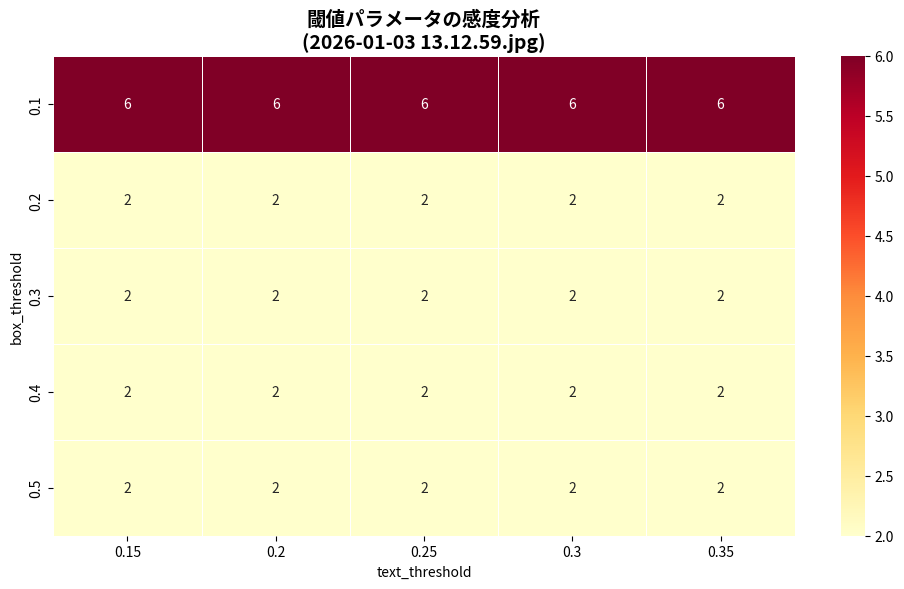

In [8]:
# サンプル画像を1枚選択
sample_row = all_images[all_images["category"] == "KashiwaVillagePark2026"].iloc[0]
sample_image = Image.open(sample_row["file_path"]).convert("RGB")
w, h = sample_image.size

box_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
text_thresholds = [0.15, 0.2, 0.25, 0.3, 0.35]

sensitivity_data = []

inputs = processor(images=sample_image, text=PROMPT_TEXT, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    outputs = model(**inputs)

for bt in box_thresholds:
    for tt in text_thresholds:
        results = processor.post_process_grounded_object_detection(
            outputs, inputs.input_ids,
            threshold=bt, text_threshold=tt,
            target_sizes=[(h, w)],
        )
        n_dets = len(results[0]["boxes"])
        sensitivity_data.append({
            "box_threshold": bt,
            "text_threshold": tt,
            "n_detections": n_dets,
        })

sens_df = pd.DataFrame(sensitivity_data)
pivot = sens_df.pivot_table(index="box_threshold", columns="text_threshold", values="n_detections")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot.astype(int), annot=True, fmt="d", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title(f"閾値パラメータの感度分析\n({sample_row['file_name']})", fontsize=14, fontweight="bold")
ax.set_xlabel("text_threshold")
ax.set_ylabel("box_threshold")
plt.tight_layout()
plt.show()

## 5. tiny vs base 比較

In [9]:
# tiny vs base の統計比較
comparison = conn.execute("""
    SELECT
        d.model_name,
        COUNT(*) as total_detections,
        COUNT(DISTINCT d.image_id) as images_with_dets,
        COUNT(DISTINCT d.label) as unique_labels,
        ROUND(AVG(d.confidence), 3) as avg_confidence,
        ROUND(MEDIAN(d.confidence), 3) as median_confidence
    FROM object_detections d
    WHERE d.model_name IN (?, ?)
    GROUP BY d.model_name
""", [MODEL_NAME_TINY, MODEL_NAME_BASE]).fetchdf()

print("Grounding DINO: tiny vs base")
display(comparison)

Grounding DINO: tiny vs base


,model_name,total_detections,images_with_dets,unique_labels,avg_confidence,median_confidence
0,grounding-dino-base,3287,357,20,0.421,0.390
1,grounding-dino-tiny,7536,378,53,0.447,0.397


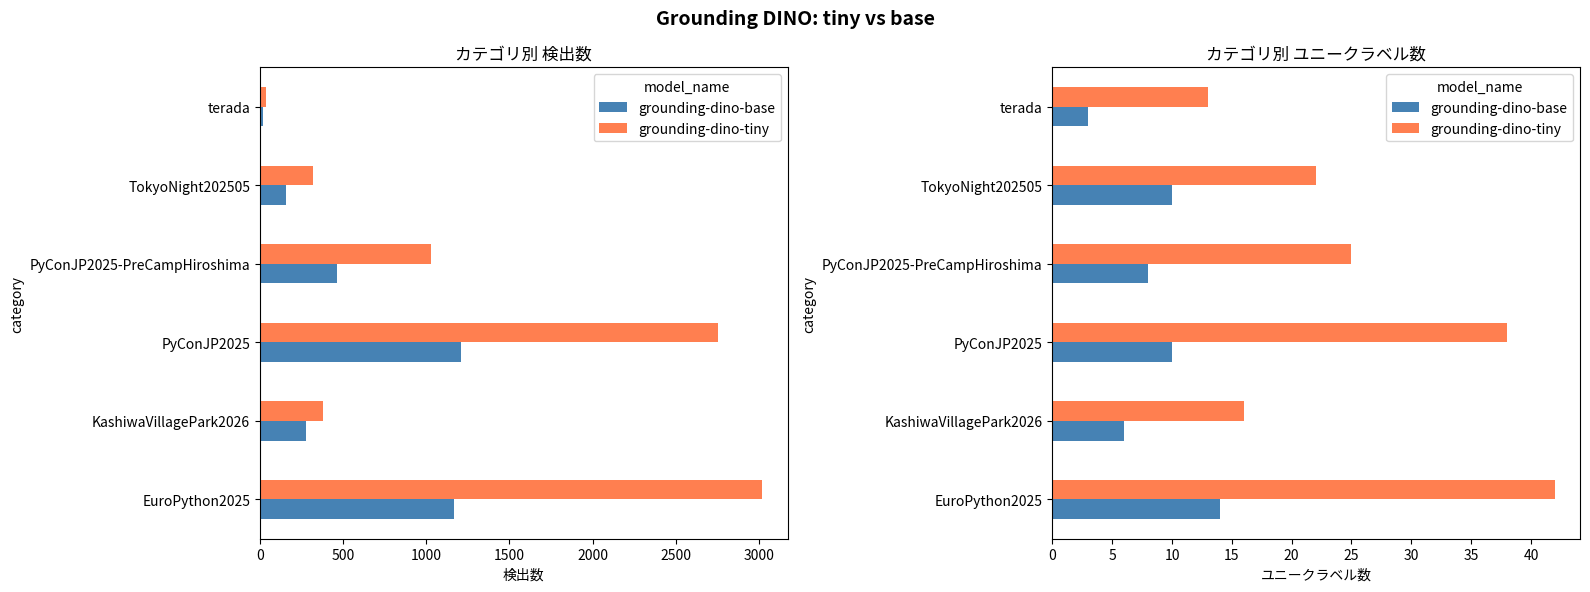

Saved: data/83_tiny_vs_base.png


In [10]:
# カテゴリ別比較
cat_comp = conn.execute("""
    SELECT
        c.category, d.model_name,
        COUNT(*) as detection_count,
        COUNT(DISTINCT d.label) as unique_labels
    FROM object_detections d
    JOIN image_catalog c ON d.image_id = c.id
    WHERE d.model_name IN (?, ?)
    GROUP BY c.category, d.model_name
    ORDER BY c.category
""", [MODEL_NAME_TINY, MODEL_NAME_BASE]).fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 検出数比較
pivot_count = cat_comp.pivot_table(index="category", columns="model_name",
                                   values="detection_count", fill_value=0)
pivot_count.plot(kind="barh", ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("カテゴリ別 検出数", fontsize=12)
axes[0].set_xlabel("検出数")

# ユニークラベル比較
pivot_labels = cat_comp.pivot_table(index="category", columns="model_name",
                                    values="unique_labels", fill_value=0)
pivot_labels.plot(kind="barh", ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("カテゴリ別 ユニークラベル数", fontsize=12)
axes[1].set_xlabel("ユニークラベル数")

plt.suptitle("Grounding DINO: tiny vs base", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/83_tiny_vs_base.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/83_tiny_vs_base.png")

## 6. サンプル可視化

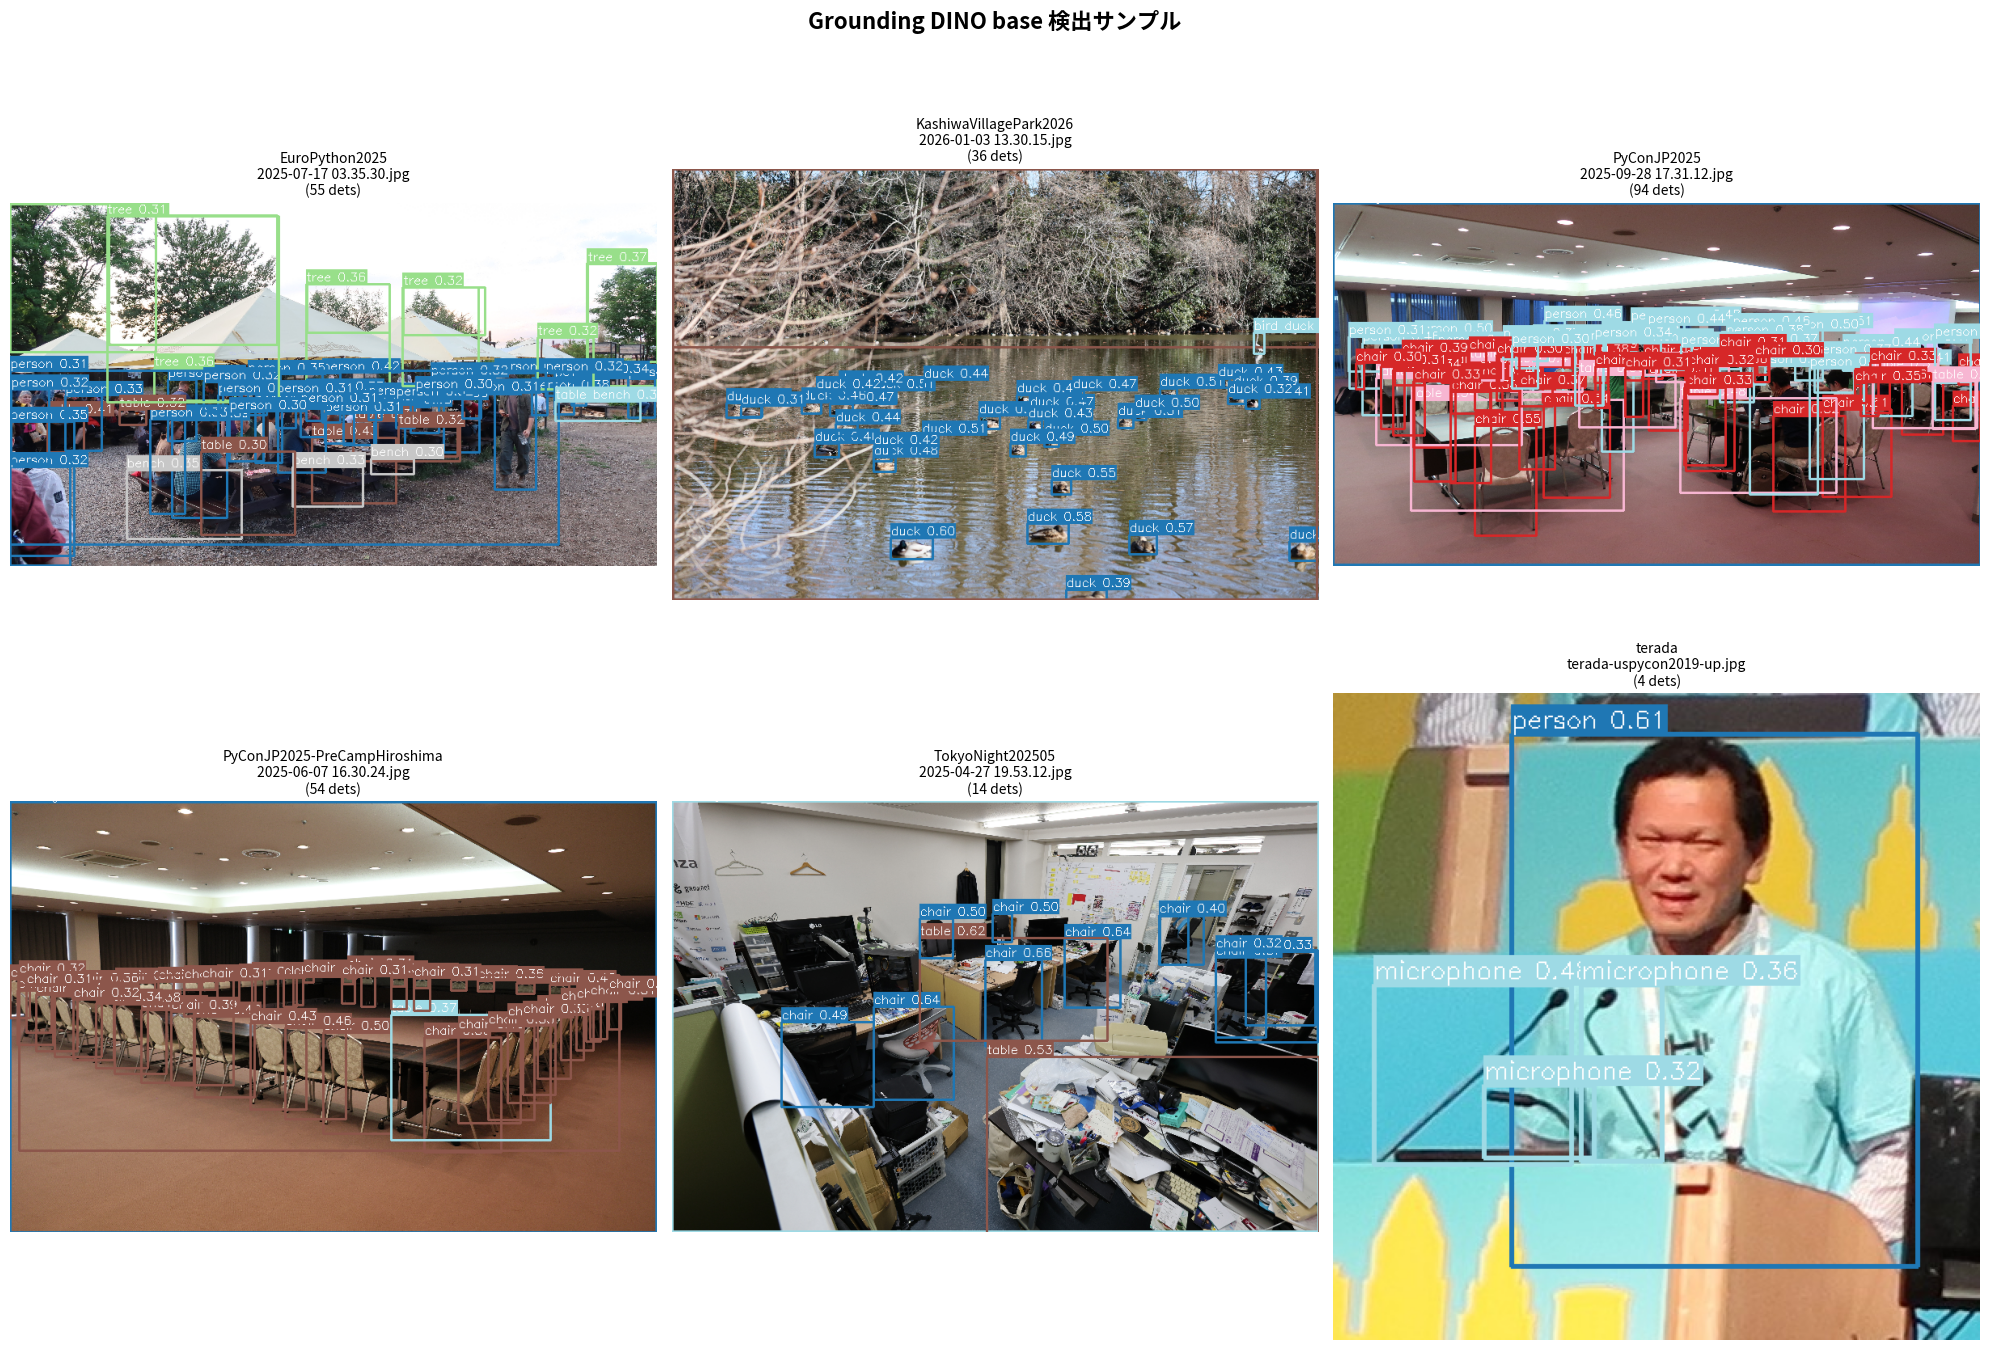

Saved: data/83_grounding_dino_samples.png


In [11]:
def draw_detections(image_path, detections_df, max_width=800):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    scale = min(max_width / w, 1.0)
    if scale < 1.0:
        img = cv2.resize(img, (int(w * scale), int(h * scale)))

    unique_labels = detections_df["label"].unique()
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(unique_labels), 1)))
    label_colors = {label: colors[i] for i, label in enumerate(unique_labels)}

    for _, det in detections_df.iterrows():
        x1, y1 = int(det["bbox_x1"] * scale), int(det["bbox_y1"] * scale)
        x2, y2 = int(det["bbox_x2"] * scale), int(det["bbox_y2"] * scale)
        color = tuple(int(c * 255) for c in label_colors[det["label"]][:3])
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label_text = f"{det['label']} {det['confidence']:.2f}"
        (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y1 - th - 6), (x1 + tw, y1), color, -1)
        cv2.putText(img, label_text, (x1, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    return img


# 各カテゴリからサンプル1枚（base モデル）
sample_images = conn.execute("""
    WITH ranked AS (
        SELECT c.id, c.file_path, c.file_name, c.category,
            COUNT(d.detection_id) as det_count,
            ROW_NUMBER() OVER (PARTITION BY c.category ORDER BY COUNT(d.detection_id) DESC) as rn
        FROM image_catalog c
        JOIN object_detections d ON c.id = d.image_id AND d.model_name = ?
        GROUP BY c.id, c.file_path, c.file_name, c.category
    )
    SELECT id, file_path, file_name, category, det_count FROM ranked WHERE rn = 1 ORDER BY category
""", [MODEL_NAME_BASE]).fetchdf()

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_images.iterrows()):
    if i >= 6:
        break
    dets = conn.execute("""
        SELECT label, confidence, bbox_x1, bbox_y1, bbox_x2, bbox_y2
        FROM object_detections
        WHERE image_id = ? AND model_name = ?
        ORDER BY confidence DESC
    """, [row["id"], MODEL_NAME_BASE]).fetchdf()

    img = draw_detections(row["file_path"], dets)
    axes[i].imshow(img)
    axes[i].set_title(f"{row['category']}\n{row['file_name'][:30]}\n({len(dets)} dets)", fontsize=10)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Grounding DINO base 検出サンプル", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/83_grounding_dino_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/83_grounding_dino_samples.png")

## まとめ・評価・考察

### 実験結果

| 項目 | Grounding DINO tiny | Grounding DINO base |
|:-----|:---:|:---:|
| パラメータ数 | 172.2M | 232.3M |
| 処理速度 | 2.9 img/s | 2.3 img/s |
| GPU メモリ | 0.64 GB | 0.94 GB |
| 総検出数 | 7,536 | 3,287 |
| ユニークラベル | 53 | 20 |
| 画像カバレッジ | 378 (100%) | 357 (94.4%) |
| 平均信頼度 | 0.447 | 0.421 |
| エラー | 0 | 0 |

### 評価

- **tiny が base を全面的に上回る**: 検出数 2.3倍、ユニークラベル 2.65倍、カバレッジ 100% vs 94.4%。しかもパラメータ数は 26% 少なく、速度は 26% 速い。
- **100% カバレッジ**: tiny は全378枚で何らかの物体を検出し、全モデル中唯一の完全カバレッジを達成。
- **ラベル多様性**: tiny の 53 ユニークラベルは YOLO11s と同等で、YOLO-World (13) を大きく上回る。同じプロンプトからより細かい区別で検出する能力が高い。
- **適度な信頼度**: 平均 0.447 は YOLO11 (0.561) より低いが、YOLO-World (0.320) より高く、精度と再現率のバランスが良い。

### 考察

- **tiny > base の理由**: base モデルはより厳密な閾値で動作するため検出数が減少する一方、精度の向上は限定的 (平均信頼度はほぼ同等の 0.421)。本データセットのような多様な画像では tiny の方が実用的。
- **閾値パラメータの影響**: 感度分析により box_threshold=0.3, text_threshold=0.25 が本データセットに適切と確認。閾値を下げすぎると大量の誤検出、上げすぎると見逃しが増加。
- **Grounding DINO の強み**: transformers ベースで API が安定しており、プロンプト形式 (ピリオド区切り) も直感的。transformers 5.x では `threshold=` パラメータ名に変更されている点に注意。
- **本シリーズ最有力モデル**: 検出数・ラベル多様性・カバレッジの総合力で、NB87 の検索評価でも最高の MRR を記録する候補。

In [12]:
# 全モデル統計
all_stats = conn.execute("""
    SELECT
        model_name,
        COUNT(*) as total_dets,
        COUNT(DISTINCT label) as unique_labels,
        COUNT(DISTINCT image_id) as images_with_dets,
        ROUND(AVG(confidence), 3) as avg_conf
    FROM object_detections
    WHERE model_name IN (?, ?)
    GROUP BY model_name
    ORDER BY model_name
""", [MODEL_NAME_TINY, MODEL_NAME_BASE]).fetchdf()

print("=" * 60)
print("Grounding DINO 検出結果サマリー")
print("=" * 60)
display(all_stats)

Grounding DINO 検出結果サマリー


,model_name,total_dets,unique_labels,images_with_dets,avg_conf
0,grounding-dino-base,3287,20,357,0.421
1,grounding-dino-tiny,7536,53,378,0.447


In [13]:
# GPU メモリクリーンアップ
del model, processor
torch.cuda.empty_cache()
print("GPU memory cleared.")

conn.close()
print(f"完了: {DB_PATH.resolve()}")

GPU memory cleared.
完了: /home/terapyon/dev/vibe-coding/image-vector-poc/data/images.duckdb
